# Page rank

📊 Jumlah node unik: 10000
🔗 Jumlah edge: 78323


Menghitung PageRank:   0%|          | 0/100 [00:00<?, ?it/s]

✅ Konvergen pada iterasi ke-57

🏆 Top 10 Node berdasarkan PageRank:
        Node  PageRank
5187  486980  0.005070
3160  285814  0.003439
2561  226374  0.002460
1903  163075  0.002413
5945  555924  0.001946
585    32163  0.001726
8885  828963  0.001586
5371  504140  0.001556
4260  396321  0.001532
6395  599130  0.001524

🔧 Membuat graph lengkap...


Menambahkan edges ke graph:   0%|          | 0/78323 [00:00<?, ?it/s]

✅ Graph selesai dibuat: 10000 node dan 78323 edge.

🎨 Membuat visualisasi (ini bisa memakan waktu lama untuk 10.000 node)...


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127760 (\N{GLOBE WITH MERIDIANS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


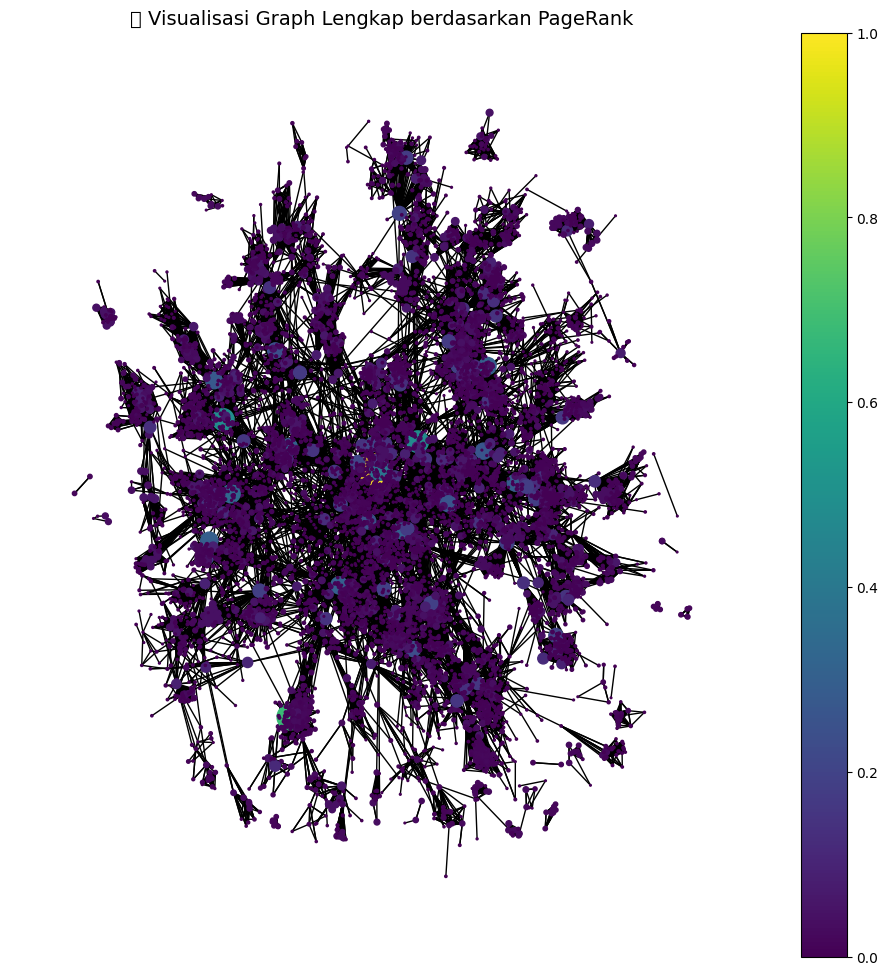

In [ ]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from tqdm.auto import tqdm

# === 1️⃣ Fungsi PageRank dengan Sparse Matrix ===
def pagerank_sparse(edges, damping=0.85, max_iter=100, tol=1e-6):
    """
    Hitung PageRank menggunakan sparse matrix.
    """
    # --- Siapkan node dan mapping index ---
    nodes = sorted(set([s for s, _ in edges] + [t for _, t in edges]))
    n = len(nodes)
    node_to_idx = {node: i for i, node in enumerate(nodes)}
    idx_to_node = {i: node for node, i in node_to_idx.items()}

    # --- Buat matriks transisi (sparse) ---
    row, col = [], []
    for s, t in edges:
        row.append(node_to_idx[t])  # in-link
        col.append(node_to_idx[s])
    data = np.ones(len(row))
    M = csr_matrix((data, (row, col)), shape=(n, n), dtype=float)

    # --- Normalisasi kolom (out-degree) ---
    out_degree = np.array(M.sum(axis=0)).flatten()
    out_degree[out_degree == 0] = 1.0
    M = M.multiply(1 / out_degree)

    # --- Inisialisasi PageRank ---
    pr = np.ones(n) / n
    teleport = (1 - damping) / n

    # --- Iterasi sampai konvergen ---
    for i in tqdm(range(max_iter), desc="Menghitung PageRank"):
        pr_new = damping * (M @ pr) + teleport
        if np.linalg.norm(pr_new - pr, 1) < tol:
            print(f"✅ Konvergen pada iterasi ke-{i+1}")
            break
        pr = pr_new

    # --- Kembalikan hasil dalam bentuk dict ---
    return {idx_to_node[i]: pr[i] for i in range(n)}

# === 2️⃣ Baca file web-Google_10k.txt ===
file_path = "web-Google_10k.txt"

edges = []
with open(file_path, 'r') as f:
    for line in f:
        if line.startswith('#'):
            continue
        parts = line.strip().split('\t')
        if len(parts) == 2:
            source, target = parts
            edges.append((int(source), int(target)))

print(f"📊 Jumlah node unik: {len(set([s for s, _ in edges] + [t for _, t in edges]))}")
print(f"🔗 Jumlah edge: {len(edges)}")

# === 3️⃣ Hitung PageRank ===
pagerank_scores = pagerank_sparse(edges)

# Simpan ke DataFrame
df_pagerank = pd.DataFrame(pagerank_scores.items(), columns=["Node", "PageRank"])
df_pagerank = df_pagerank.sort_values(by="PageRank", ascending=False)
print("\n🏆 Top 10 Node berdasarkan PageRank:")
print(df_pagerank.head(10))

# === 4️⃣ Buat graph lengkap ===
print("\n🔧 Membuat graph lengkap...")
G = nx.DiGraph()
for edge in tqdm(edges, desc="Menambahkan edges ke graph"):
    G.add_edge(*edge)

print(f"✅ Graph selesai dibuat: {G.number_of_nodes()} node dan {G.number_of_edges()} edge.")

# === 5️⃣ Visualisasi graph penuh ===
print("\n🎨 Membuat visualisasi (ini bisa memakan waktu lama untuk 10.000 node)...")
fig, ax = plt.subplots(figsize=(12, 12))

# Gunakan layout yang relatif cepat
pos = nx.spring_layout(G, seed=42)

# Warna dan ukuran node berdasarkan PageRank
node_color = [pagerank_scores.get(node, 0) for node in G.nodes()]
node_size = [v * 100000 for v in node_color]

# Gambar graph
nodes = nx.draw(
    G,
    pos,
    node_size=node_size,
    node_color=node_color,
    cmap=plt.cm.viridis,
    arrows=False,
    with_labels=False,
    ax=ax,
)

# Tambahkan colorbar dengan axis yang benar
fig.colorbar(nodes, ax=ax)
plt.title("🌐 Visualisasi Graph Lengkap berdasarkan PageRank", fontsize=14)
plt.show()


🔗 Total edges: 5514
📄 Total unique pages: 245


Menghitung PageRank:   0%|          | 0/100 [00:00<?, ?it/s]

✅ Konvergen pada iterasi ke-9

🏆 Top 10 Halaman berdasarkan PageRank:
                                                  Page  PageRank
8           http://teknik.trunojoyo.ac.id/tracer-study  0.001014
37                     https://teknik.trunojoyo.ac.id/  0.001014
207  https://teknik.trunojoyo.ac.id/statistik-prest...  0.001014
206  https://teknik.trunojoyo.ac.id/sistem-informas...  0.000921
216     https://teknik.trunojoyo.ac.id/teknik-mesin-3/  0.000921
212  https://teknik.trunojoyo.ac.id/teknik-industri-3/  0.000921
211   https://teknik.trunojoyo.ac.id/teknik-elektro-2/  0.000921
215  https://teknik.trunojoyo.ac.id/teknik-mekatron...  0.000921
213  https://teknik.trunojoyo.ac.id/teknik-informat...  0.000913
44            https://teknik.trunojoyo.ac.id/about-us/  0.000844

🔧 Membuat graph lengkap...


Menambahkan edges ke graph:   0%|          | 0/5514 [00:00<?, ?it/s]

✅ Graph selesai dibuat: 245 node dan 2664 edge.

🎨 Membuat visualisasi graph... (bisa memakan waktu untuk dataset besar)


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127760 (\N{GLOBE WITH MERIDIANS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


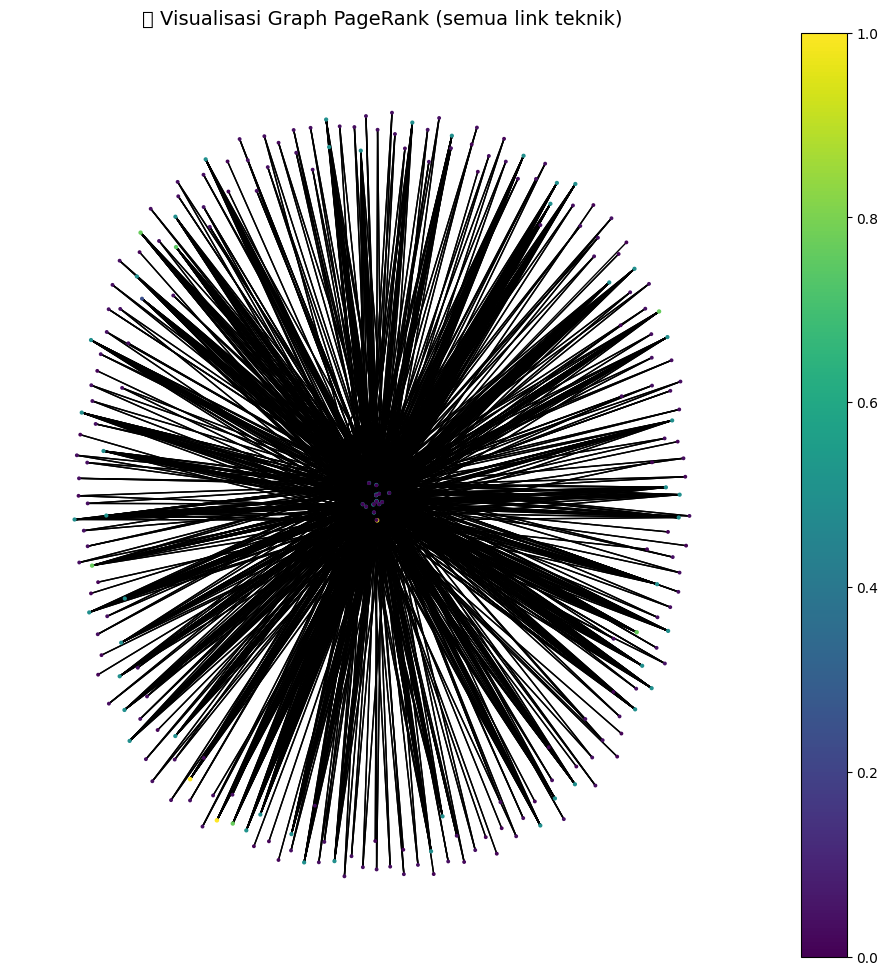

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from tqdm.auto import tqdm

# === 1️⃣ Fungsi PageRank Sparse ===
def pagerank_sparse(edges, damping=0.85, max_iter=100, tol=1e-6):
    """
    Hitung PageRank menggunakan sparse matrix.
    """
    # --- Siapkan node dan mapping index ---
    nodes = sorted(set([s for s, _ in edges] + [t for _, t in edges]))
    n = len(nodes)
    node_to_idx = {node: i for i, node in enumerate(nodes)}
    idx_to_node = {i: node for node, i in node_to_idx.items()}

    # --- Buat matriks transisi (sparse) ---
    row, col = [], []
    for s, t in edges:
        row.append(node_to_idx[t])  # in-link
        col.append(node_to_idx[s])
    data = np.ones(len(row))
    M = csr_matrix((data, (row, col)), shape=(n, n), dtype=float)

    # --- Normalisasi kolom (out-degree) ---
    out_degree = np.array(M.sum(axis=0)).flatten()
    out_degree[out_degree == 0] = 1.0
    M = M.multiply(1 / out_degree)

    # --- Inisialisasi PageRank ---
    pr = np.ones(n) / n
    teleport = (1 - damping) / n

    # --- Iterasi sampai konvergen ---
    for i in tqdm(range(max_iter), desc="Menghitung PageRank"):
        pr_new = damping * (M @ pr) + teleport
        if np.linalg.norm(pr_new - pr, 1) < tol:
            print(f"✅ Konvergen pada iterasi ke-{i+1}")
            break
        pr = pr_new

    return {idx_to_node[i]: pr[i] for i in range(n)}

# === 2️⃣ Baca Dataset ===
df = pd.read_csv("semua_link_teknik.csv")

# Pastikan tidak ada nilai kosong
df = df.dropna(subset=["Page", "Link Keluar"])

# Buat daftar edges (source → target)
edges = list(zip(df["Page"], df["Link Keluar"]))

print(f"🔗 Total edges: {len(edges)}")
print(f"📄 Total unique pages: {len(set(df['Page']).union(set(df['Link Keluar'])))}")

# === 3️⃣ Hitung PageRank ===
pagerank_scores = pagerank_sparse(edges)

# Simpan ke DataFrame
df_pagerank = pd.DataFrame(pagerank_scores.items(), columns=["Page", "PageRank"])
df_pagerank = df_pagerank.sort_values(by="PageRank", ascending=False)

print("\n🏆 Top 10 Halaman berdasarkan PageRank:")
print(df_pagerank.head(10))

# === 4️⃣ Buat Graph Lengkap ===
print("\n🔧 Membuat graph lengkap...")
G = nx.DiGraph()
for edge in tqdm(edges, desc="Menambahkan edges ke graph"):
    G.add_edge(*edge)

print(f"✅ Graph selesai dibuat: {G.number_of_nodes()} node dan {G.number_of_edges()} edge.")

# === 5️⃣ Visualisasi Graph ===
print("\n🎨 Membuat visualisasi graph... (bisa memakan waktu untuk dataset besar)")

fig, ax = plt.subplots(figsize=(12, 12))
pos = nx.spring_layout(G, seed=42)  # layout posisi node

# Warna dan ukuran node berdasarkan PageRank
node_color = [pagerank_scores.get(node, 0) for node in G.nodes()]
node_size = [v * 5000 for v in node_color]

nodes = nx.draw(
    G,
    pos,
    node_size=node_size,
    node_color=node_color,
    cmap=plt.cm.viridis,
    arrows=False,
    with_labels=False,
    ax=ax
)

# Tambahkan colorbar
fig.colorbar(nodes, ax=ax)
plt.title("🌐 Visualisasi Graph PageRank (semua link teknik)", fontsize=14)
plt.show()
